In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset = pd.read_csv(r'placementdata.csv')
dataset.drop(columns=['StudentID'],inplace=True)

In [4]:
dataset.head()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [33]:
dataset["HSC_Marks"].describe()

count    10000.000000
mean        74.501500
std          8.919527
min         57.000000
25%         67.000000
50%         73.000000
75%         83.000000
max         88.000000
Name: HSC_Marks, dtype: float64

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(dataset.drop(columns=['PlacementStatus']),dataset['PlacementStatus'],test_size=0.2,random_state=2)

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

transformer = ColumnTransformer(transformers=[
    ('tnf',OrdinalEncoder(categories=[['No','Yes'],['No','Yes']]),['ExtracurricularActivities','PlacementTraining'])
], remainder='passthrough')

X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
#model training and testing
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lr = LogisticRegression()
lr.fit(X_train_scaled,y_train_encoded)
y_pred_lr = lr.predict(X_test_scaled)

In [11]:
accuracy = accuracy_score(y_test_encoded, y_pred_lr)

print("Logistic Regression: ",accuracy)

cr = classification_report(y_test_encoded, y_pred_lr)
print(cr)

cm = confusion_matrix(y_test_encoded, y_pred_lr)

print(cm)

Logistic Regression:  0.811
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1123
           1       0.78      0.79      0.78       877

    accuracy                           0.81      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.81      0.81      0.81      2000

[[933 190]
 [188 689]]


In [12]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

pred = dt.predict(X_test)

print("Decision Tree:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

Decision Tree: 0.715
              precision    recall  f1-score   support

   NotPlaced       0.74      0.75      0.75      1123
      Placed       0.68      0.66      0.67       877

    accuracy                           0.71      2000
   macro avg       0.71      0.71      0.71      2000
weighted avg       0.71      0.71      0.71      2000

[[847 276]
 [294 583]]


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train_scaled, y_train_encoded)

pred1 = rf.predict(X_test_scaled)

print("Random Forest:", accuracy_score(y_test_encoded, pred1))
print(classification_report(y_test_encoded, pred1))
print(confusion_matrix(y_test_encoded, pred1))

Random Forest: 0.802
              precision    recall  f1-score   support

           0       0.81      0.84      0.83      1123
           1       0.79      0.75      0.77       877

    accuracy                           0.80      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.80      0.80      0.80      2000

[[943 180]
 [216 661]]


In [14]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.8110,
        0.7150,
        0.8020
    ],
    "Precision": [
        0.81,
        0.71,
        0.80
    ],
    "Recall": [
        0.81,
        0.71,
        0.80
    ],
    "F1-Score": [
        0.81,
        0.71,
        0.80
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.811,0.81,0.81,0.81
1,Decision Tree,0.715,0.71,0.71,0.71
2,Random Forest,0.802,0.80,0.80,0.80


Observations:

The Logistic Regression model performs the best among the three trained models and achieves the highest accuracy (81.1%) along with the best balance of precision, recall, and F1-score. Although Random Forest also performed well, Logistic Regression was selected as the final model due to its slightly better performance and greater interpretability.

In [15]:
feature_names = transformer.get_feature_names_out()
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr.coef_[0]
})

coef_df["Importance"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values("Importance", ascending=False)

coef_df["Feature"] = (
    coef_df["Feature"]
    .str.replace("remainder__", "", regex=False)
    .str.replace("tnf__", "", regex=False)
)
coef_df = coef_df.reset_index(drop=True)

coef_df

,Feature,Coefficient,Importance
0,AptitudeTestScore,0.571238,0.571238
1,PlacementTraining,0.386670,0.386670
2,ExtracurricularActivities,0.383821,0.383821
3,SSC_Marks,0.301615,0.301615
4,SoftSkillsRating,0.285507,0.285507
5,CGPA,0.261016,0.261016
6,HSC_Marks,0.245240,0.245240
7,Projects,0.192116,0.192116
8,Workshops/Certifications,0.095532,0.095532
9,Internships,-0.003658,0.003658


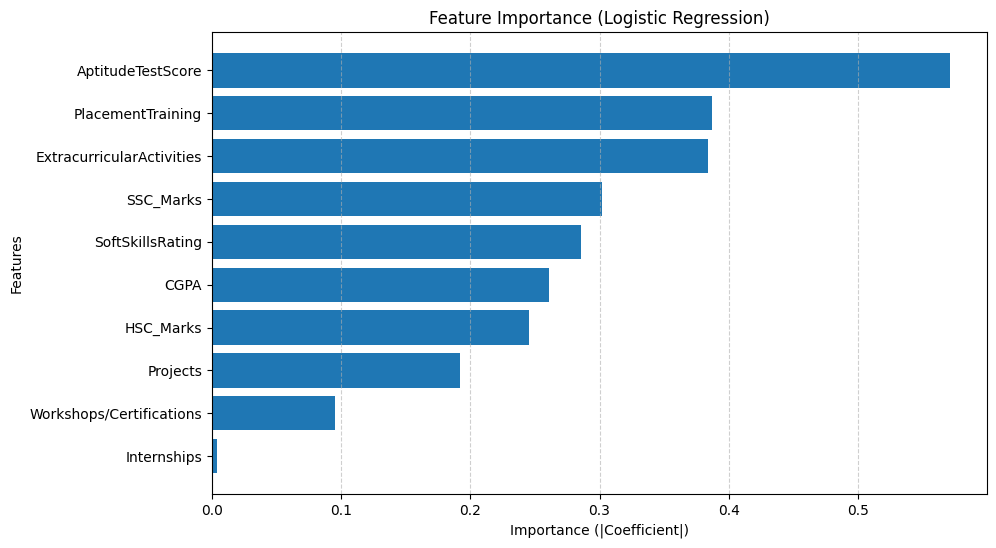

In [16]:
plt.figure(figsize=(10,6))

plt.barh(
    coef_df["Feature"],
    coef_df["Importance"]
)

plt.xlabel("Importance (|Coefficient|)")
plt.ylabel("Features")
plt.title("Feature Importance (Logistic Regression)")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.show()

Observations:

We use the absolute values of the logistic regression coefficients to measure feature importance. Features with larger absolute coefficients have a greater influence on the prediction, while the sign of the original coefficient indicates whether the feature increases or decreases the probability of placement.

From the graph, we see that AptitudeTestScore has the the highest importance for the model (0.57), followed by PlacementTraining (0.386) and ExtracurricularActivities (0.383) and Internships showing the least importance.

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score
y_prob = lr.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_encoded, y_prob)
roc_auc = roc_auc_score(y_test_encoded, y_prob)

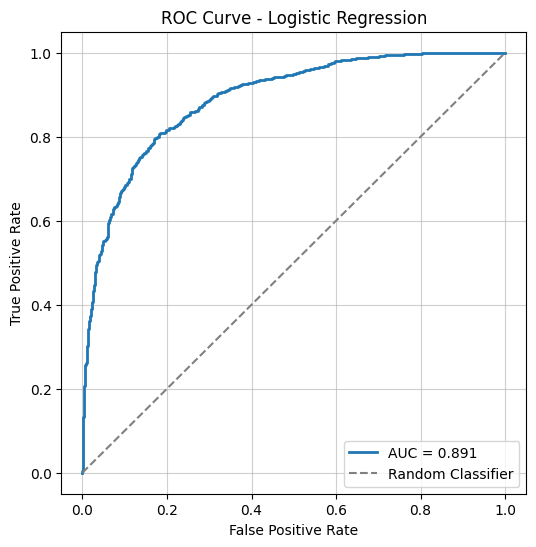

In [18]:
plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], '--', color='gray', label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(alpha=0.6)

plt.show()

In [19]:
#function for threshold levels for placement chances
def placement_chance(prob):
    if prob < 0.30:
        return "🔴 Low Chance"
    elif prob < 0.70:
        return "🟡 Medium Chance"
    else:
        return "🟢 High Chance"

placement_levels = pd.Series(y_prob).apply(placement_chance)

In [20]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Placement Probability": (y_prob * 100).round(2),
    "Placement Chance": placement_levels
})

results.head(10)

,Actual,Placement Probability,Placement Chance
0,NotPlaced,12.67,🔴 Low Chance
1,NotPlaced,1.13,🔴 Low Chance
2,Placed,86.00,🟢 High Chance
3,NotPlaced,4.74,🔴 Low Chance
4,NotPlaced,25.28,🔴 Low Chance
5,Placed,87.09,🟢 High Chance
6,NotPlaced,25.52,🔴 Low Chance
7,Placed,35.80,🟡 Medium Chance
8,NotPlaced,42.50,🟡 Medium Chance
9,Placed,89.87,🟢 High Chance


In [21]:
priority_features = [
    "AptitudeTestScore",
    "PlacementTraining",
    "ExtracurricularActivities",
    "SoftSkillsRating",
    "CGPA",
    "Projects",
    "Workshops/Certifications",
    "Internships"
]

thresholds = {
    "AptitudeTestScore": 70,
    "SoftSkillsRating": 7,
    "CGPA": 7.5,
    "Projects": 3,
    "Workshops/Certifications": 2,
    "Internships": 1
}

def generate_suggestions(student):

    suggestions = []

    for feature in priority_features:

        if feature == "AptitudeTestScore":
            if student[feature] < thresholds[feature]:
                suggestions.append(
                    "Improve your aptitude score by practicing quantitative aptitude, logical reasoning, and verbal ability regularly."
                )

        elif feature == "PlacementTraining":
            if student[feature] == "No":
                suggestions.append(
                    "Participate in placement training programs to improve interview preparation and placement readiness."
                )

        elif feature == "ExtracurricularActivities":
            if student[feature] == "No":
                suggestions.append(
                    "Participate in extracurricular activities such as technical clubs, hackathons, volunteering, or leadership events."
                )

        elif feature == "SoftSkillsRating":
            if student[feature] < thresholds[feature]:
                suggestions.append(
                    "Improve your communication, teamwork, and interview skills through regular practice and mock interviews."
                )

        elif feature == "CGPA":
            if student[feature] < thresholds[feature]:
                suggestions.append(
                    "Improve your CGPA to strengthen your academic profile."
                )

        elif feature == "Projects":
            if student[feature] < thresholds[feature]:
                suggestions.append(
                    "Build more practical projects to strengthen your portfolio."
                )

        elif feature == "Workshops/Certifications":
            if student[feature] < thresholds[feature]:
                suggestions.append(
                    "Complete additional workshops or industry-recognized certifications to enhance your skills."
                )

        elif feature == "Internships":
            if student[feature] < thresholds[feature]:
                suggestions.append(
                    "Gain internship experience to improve your practical knowledge and industry exposure."
                )

    if len(suggestions) == 0:
        suggestions.append(
            "Great profile! Continue maintaining your academic performance and keep practicing for placement interviews."
        )

    return suggestions[:3]

In [22]:
import joblib

joblib.dump(lr, "logistic_regression_model.pkl")

joblib.dump(transformer, "preprocessor.pkl")

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [23]:
import sklearn
import joblib

print(sklearn.__version__)
print(joblib.__version__)

1.9.0
1.5.2
